In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

df = pd.read_csv("../data/superstore_cleaned.csv")

df.head()

,Order_ID,Invoice_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Region,State,Category,Sub_Category,Product_Name,Quantity,Discount,Sales,Profit
0,ORD-10000,INV-50000,2024-04-12,2024-04-13,Second Class,CUST-1075,Customer 0227,Home Office,South,Virginia,Furniture,Chairs,Desk Lamp,6,0.15,1376.680,195.36
1,ORD-10001,INV-50001,2025-03-11,2025-03-15,Standard Class,CUST-1236,Customer 0042,Consumer,East,New Jersey,Technology,Copiers,Monitor,3,0.00,789.880,153.36
2,ORD-10002,INV-50002,2024-09-27,2024-09-30,First Class,CUST-1197,Customer 0134,Home Office,West,Arizona,Office Supplies,Envelopes,Labels,6,0.05,332.730,59.73
3,ORD-10003,INV-50003,2024-04-16,2024-04-20,Second Class,CUST-1009,Customer 0005,Home Office,West,Colorado,Office Supplies,Paper,Labels,1,0.00,107.800,14.52
4,ORD-10004,INV-50004,2024-03-12,2024-03-15,First Class,CUST-1291,Customer 0026,Home Office,East,New York,Technology,Accessories,Printer,5,0.00,3074.035,366.03


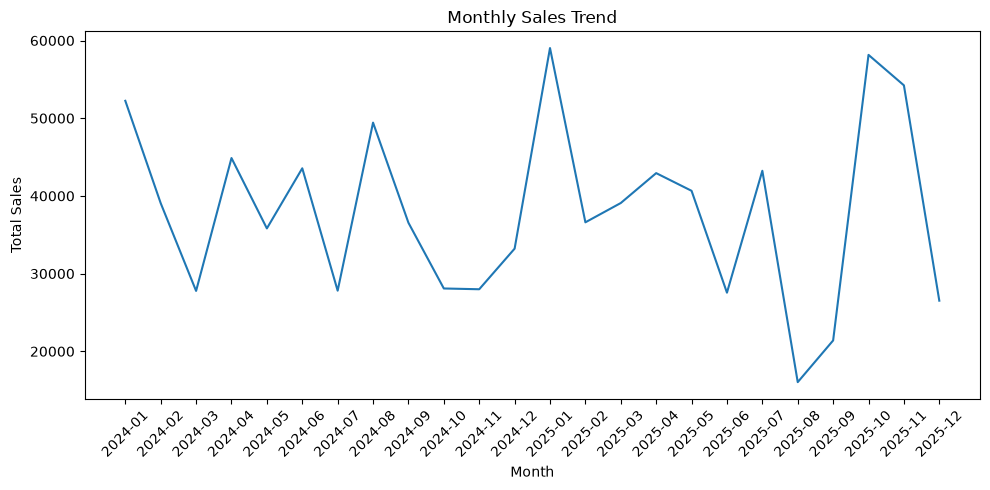

In [3]:
plt.figure(figsize=(10, 5))

monthly_sales = df.groupby(
    pd.to_datetime(df["Order_Date"]).dt.to_period("M")
)["Sales"].sum()

monthly_sales.index = monthly_sales.index.astype(str)

plt.plot(monthly_sales.index, monthly_sales.values)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("../visualizations/line_chart.png")
plt.show()

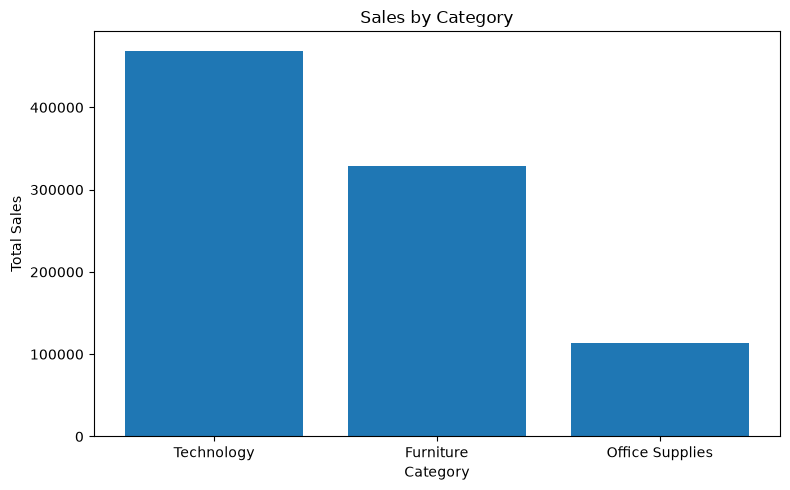

In [4]:
category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

plt.bar(category_sales.index, category_sales.values)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.savefig("../visualizations/bar_chart.png")
plt.show()

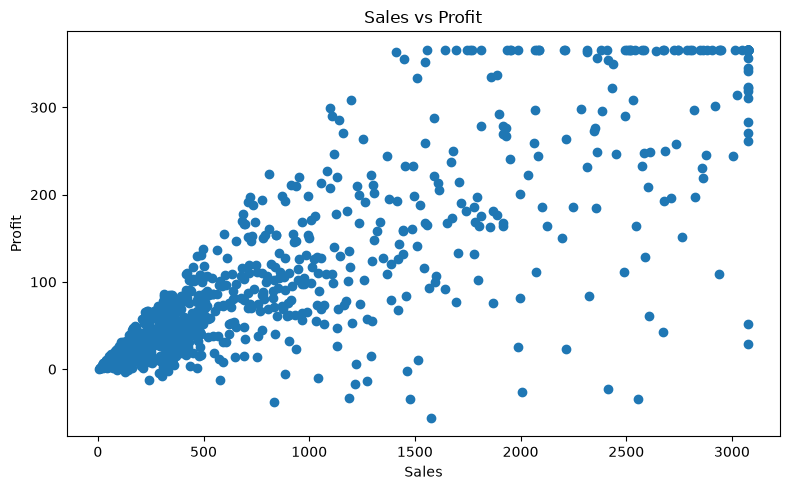

In [5]:
plt.figure(figsize=(8, 5))

plt.scatter(df["Sales"], df["Profit"])

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.tight_layout()
plt.savefig("../visualizations/scatter_plot.png")
plt.show()

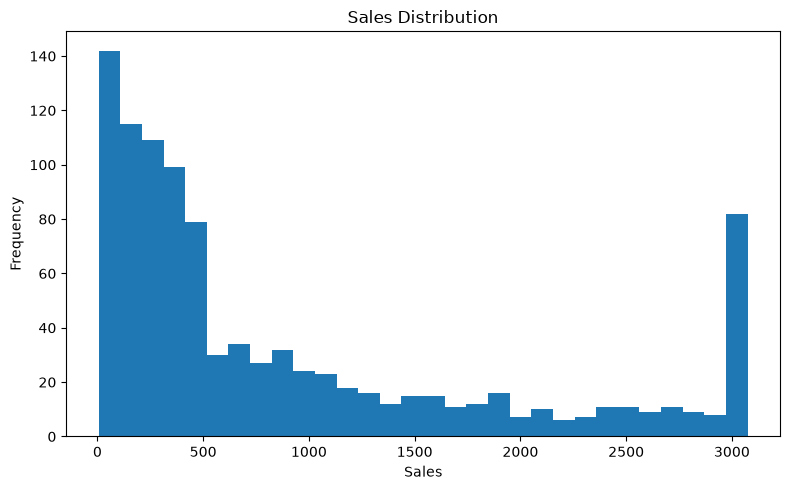

In [6]:
plt.figure(figsize=(8, 5))

plt.hist(df["Sales"], bins=30)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig("../visualizations/histogram.png")
plt.show()

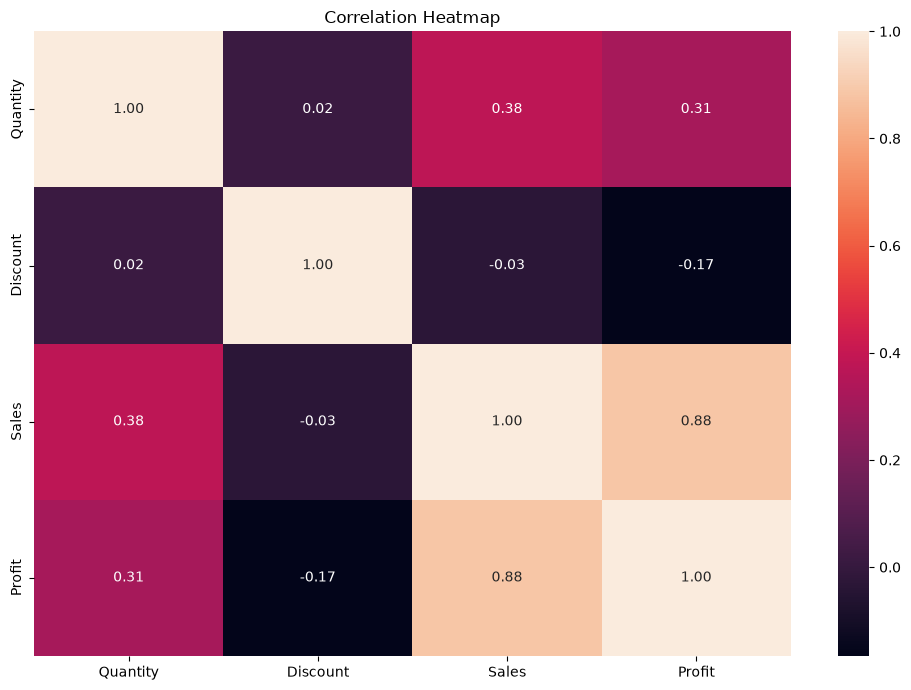

In [7]:
numeric_df = df.select_dtypes(include="number")

plt.figure(figsize=(10, 7))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.savefig("../visualizations/heatmap.png")
plt.show()

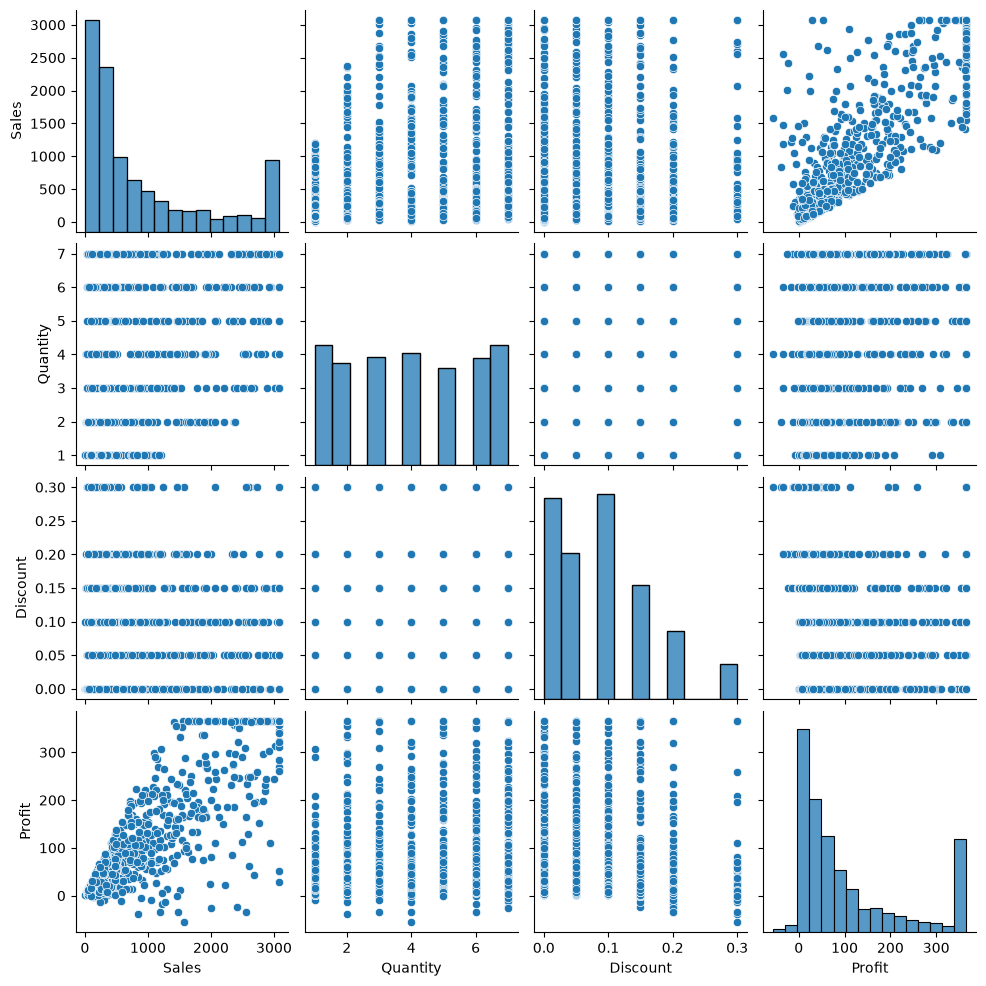

In [8]:
pair_data = df[["Sales", "Quantity", "Discount", "Profit"]].dropna()

sns.pairplot(pair_data)

plt.savefig("../visualizations/pairplot.png")
plt.show()

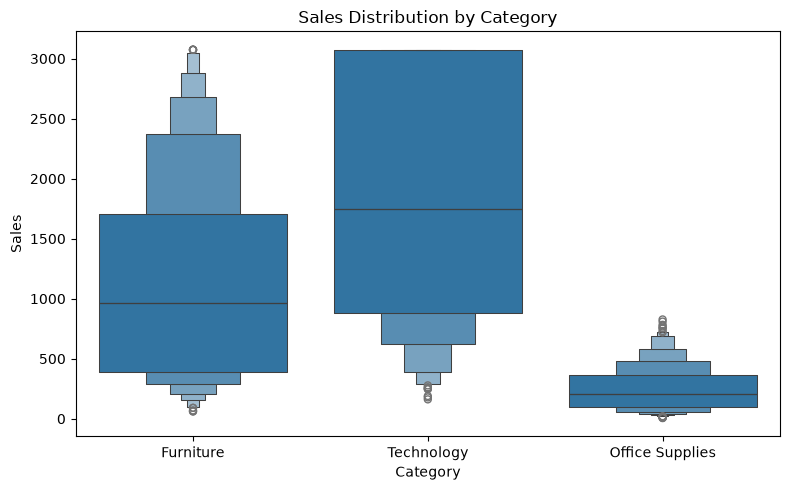

In [9]:
plt.figure(figsize=(8, 5))

sns.boxenplot(
    data=df,
    x="Category",
    y="Sales"
)

plt.title("Sales Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.tight_layout()
plt.savefig("../visualizations/boxen_plot.png")
plt.show()

In [12]:
category_sales_df = (
    df.groupby("Category")["Sales"]
    .sum()
    .reset_index()
)

fig = px.bar(
    category_sales_df,
    x="Category",
    y="Sales",
    title="Interactive Sales by Category"
)

fig.write_html("../visualizations/interactive_category_sales.html")

fig.show(renderer="browser")

In [13]:
total_sales = df["Sales"].sum()

total_customers = df["Customer_ID"].nunique()

total_orders = df["Order_ID"].nunique()

print("Total Sales:", total_sales)
print("Total Customers:", total_customers)
print("Total Orders:", total_orders)

Total Sales: 911874.72
Total Customers: 289
Total Orders: 1000


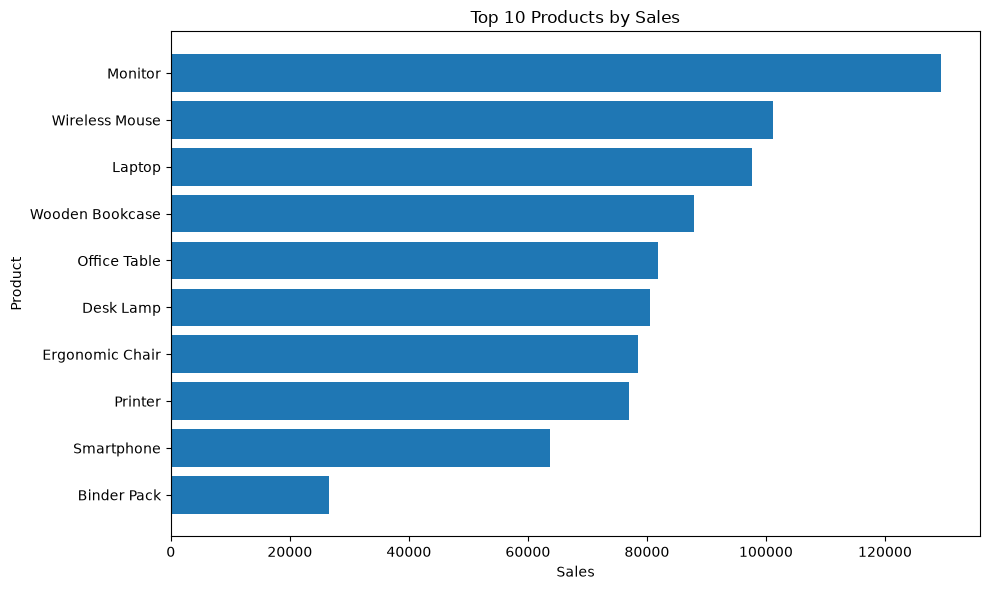

In [14]:
top_products = (
    df.groupby("Product_Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_products.index[::-1],
    top_products.values[::-1]
)

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")

plt.tight_layout()
plt.savefig("../visualizations/top_10_products.png")
plt.show()

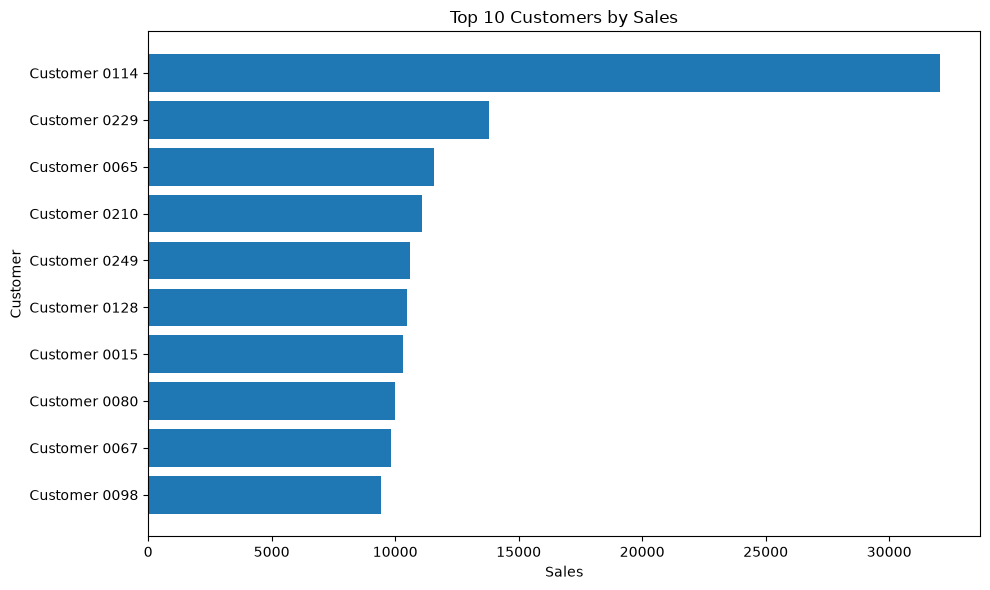

In [15]:
top_customers = (
    df.groupby("Customer_Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_customers.index[::-1],
    top_customers.values[::-1]
)

plt.title("Top 10 Customers by Sales")
plt.xlabel("Sales")
plt.ylabel("Customer")

plt.tight_layout()
plt.savefig("../visualizations/top_10_customers.png")
plt.show()